In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
import pickle


In [2]:
# Load mixing ratios and metrics
filename = "../results/mixing_results_by_group_three_groups.pickle"
with open(filename, "rb") as pickleFile:
    mixing_results_by_group = pickle.load(pickleFile)

for label in mixing_results_by_group:
    assert len(mixing_results_by_group[label]["ps"]) == len(mixing_results_by_group[label]["metrics"])
    print(f"{label}: {len(mixing_results_by_group[label]['ps'])} trials")
    
    ps = mixing_results_by_group[label]["ps"]
    group_labels = set(ps[0].keys())
    assert np.all([group_labels == set(p.keys()) for p in ps])
    
    metric_dicts = mixing_results_by_group[label]["metrics"]
    metric_names = set(metric_dicts[0].keys())
    assert np.all([metric_names == set(metric_dict.keys()) for metric_dict in metric_dicts])

18: 2001 trials
25: 2001 trials
35: 2001 trials


## Analyzing Best Mixing Ratios

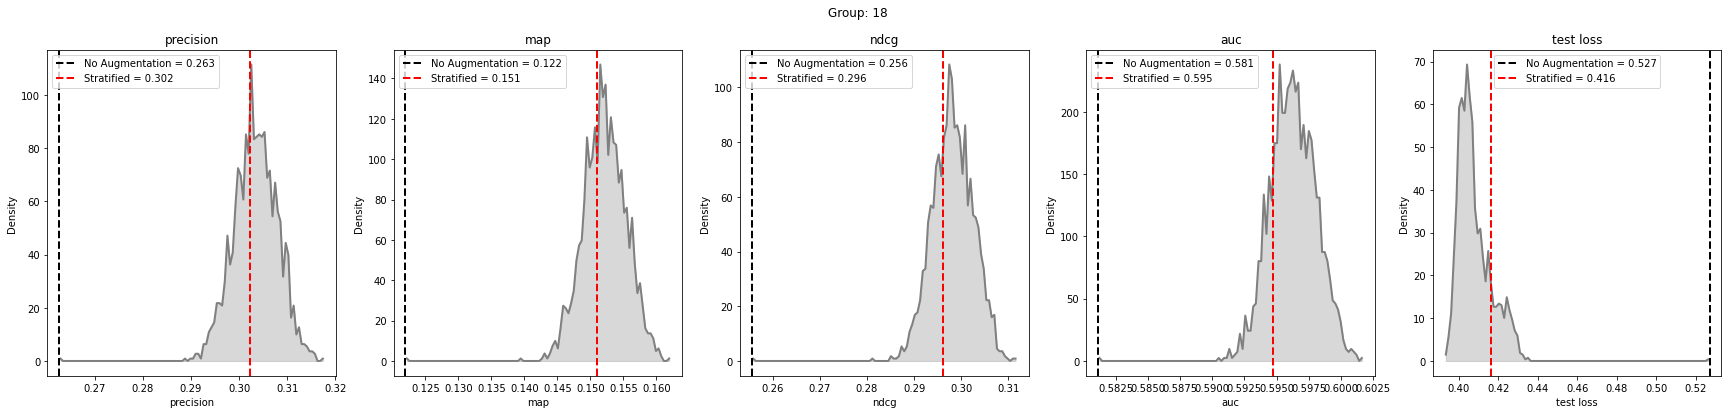

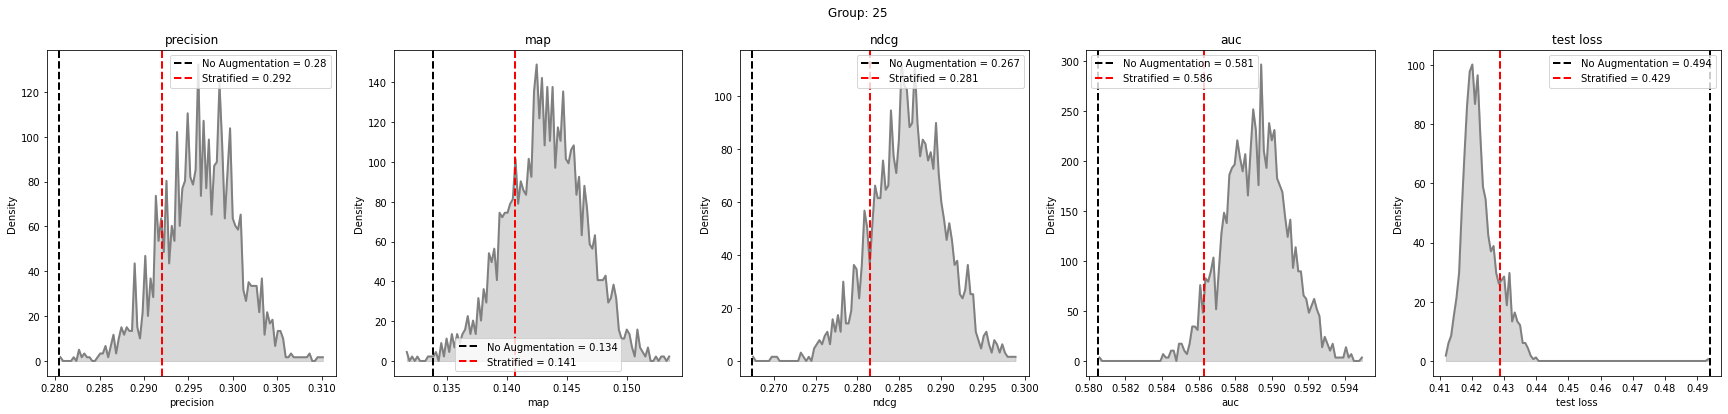

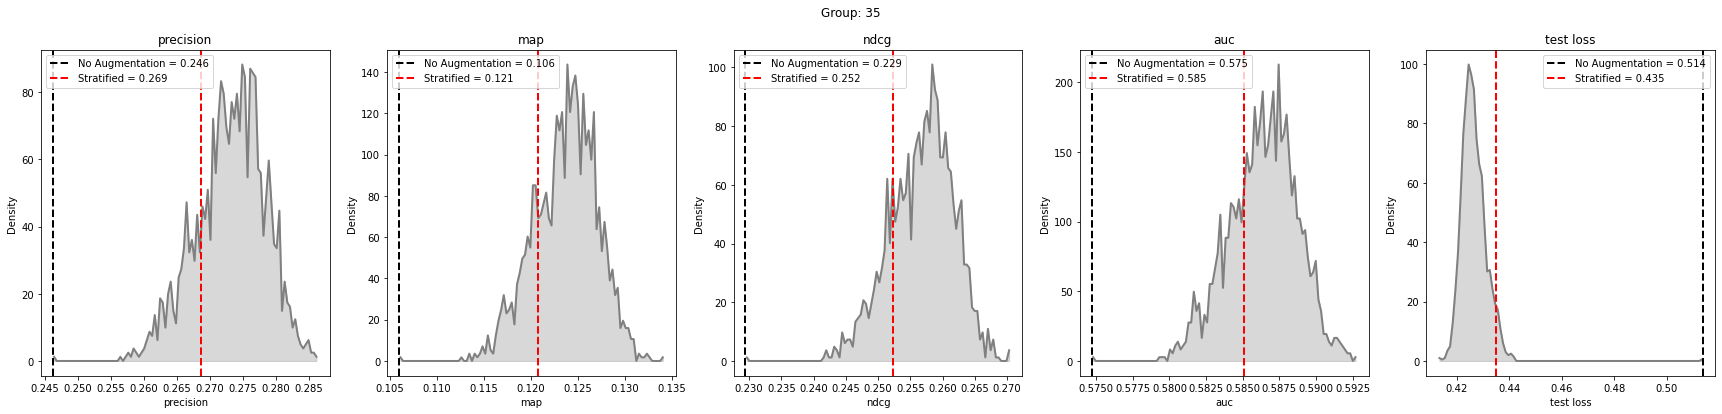

In [5]:
colors = ["black", "red"]
def plot_density_with_baseline(values, baseline_tuples, value_name="Values", title="Density Plot", ax=None):
    """
    Pure Matplotlib density plot with a vertical dashed baseline line.
    """
    values = np.asarray(values)

    # Compute histogram-based density estimate
    density, bins = np.histogram(values, bins=100, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])

    if ax == None:
        fig, ax = plt.subplots()

    ax.plot(centers, density, linewidth=2, color="gray")
    ax.fill_between(centers, density, alpha=0.3, color="gray")

    for baseline_idx, (baseline_name, baseline_val) in enumerate(baseline_tuples):
        ax.axvline(baseline_val, 
                   color=colors[baseline_idx],
                   linestyle="--", linewidth=2, 
                   label=f"{baseline_name} = {round(baseline_val, 3)}")

    ax.set_title(title)
    ax.set_xlabel(value_name)
    ax.set_ylabel("Density")
    ax.legend()

for label in mixing_results_by_group:
    metric_names = list(mixing_results_by_group[label]["metrics"][0].keys())
    metric_dicts = mixing_results_by_group[label]["metrics"]
    
    fig, axs = plt.subplots(ncols=len(metric_names), figsize=(6*len(metric_names), 6))
    fig.suptitle(f"Group: {label}")
    for metric_idx, metric_name in enumerate(metric_names):
        metric_vals = [metric_dict[metric_name] for metric_dict in metric_dicts]
        plot_density_with_baseline(metric_vals,
                                  [("No Augmentation", metric_vals[0]), ("Stratified", metric_vals[1])],
                                  value_name=metric_name,
                                  title=metric_name,
                                  ax=axs[metric_idx])


In [34]:
metric_name = "test loss"

for label in mixing_results_by_group:
    print(label)
    metric_dicts = mixing_results_by_group[label]["metrics"]
    
    ps = mixing_results_by_group[label]["ps"]
    group_labels = set(ps[0].keys())
    
    test_losses = [metric_dict[metric_name] for metric_dict in metric_dicts]
    idxs_sorted = np.argsort(test_losses)
    
    for idx in idxs_sorted[:10]:
        p = ps[idx]
        loss = test_losses[idx]
        
        rounded_p = {label: round(p[label], 2) for label in group_labels}
        print(f"{round(loss, 3)} \t {rounded_p}")
    print('\n')

18
0.393 	 {'35': 0.61, '18': 0.01, '25': 0.38}
0.393 	 {'35': 0.49, '18': 0.23, '25': 0.28}
0.393 	 {'35': 0.73, '18': 0.18, '25': 0.09}
0.394 	 {'35': 0.52, '18': 0.0, '25': 0.48}
0.394 	 {'35': 0.6, '18': 0.0, '25': 0.4}
0.394 	 {'35': 0.56, '18': 0.04, '25': 0.4}
0.394 	 {'35': 0.39, '18': 0.01, '25': 0.6}
0.394 	 {'35': 0.9, '18': 0.06, '25': 0.04}
0.395 	 {'35': 0.48, '18': 0.23, '25': 0.29}
0.395 	 {'35': 0.4, '18': 0.06, '25': 0.54}


25
0.411 	 {'35': 0.29, '18': 0.0, '25': 0.71}
0.412 	 {'35': 0.55, '18': 0.29, '25': 0.16}
0.412 	 {'35': 0.86, '18': 0.13, '25': 0.0}
0.412 	 {'35': 0.9, '18': 0.06, '25': 0.04}
0.412 	 {'35': 0.37, '18': 0.31, '25': 0.32}
0.412 	 {'35': 0.61, '18': 0.01, '25': 0.38}
0.413 	 {'35': 0.33, '18': 0.01, '25': 0.66}
0.413 	 {'35': 0.66, '18': 0.08, '25': 0.26}
0.413 	 {'35': 0.38, '18': 0.03, '25': 0.59}
0.413 	 {'35': 0.22, '18': 0.0, '25': 0.78}


35
0.413 	 {'35': 0.56, '18': 0.04, '25': 0.4}
0.414 	 {'35': 0.27, '18': 0.18, '25': 0.55}
0.415 	 {'

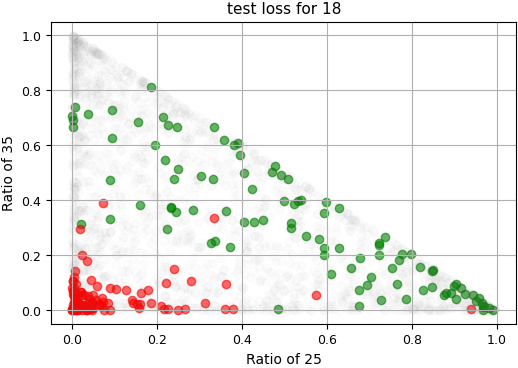

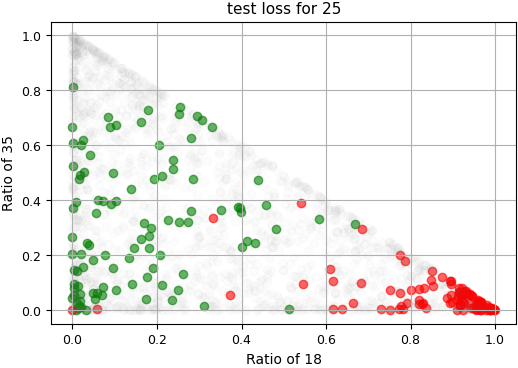

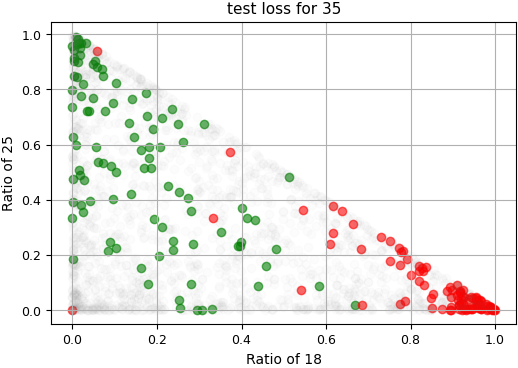

In [46]:
## Parameters
metric_name = "test loss"

labels = [
    ("18", "25", "35"),
    ("25", "18", "35"),
    ("35", "18", "25")
]

top_k = 100

## Mixing results
metric_dicts = np.array(mixing_results_by_group[base_label]["metrics"])
ps = np.array(mixing_results_by_group[label]["ps"])

test_losses = [metric_dict[metric_name] for metric_dict in metric_dicts]
idxs_sorted = np.argsort(test_losses)

## Plotting
for base_label, x_label, y_label in labels:
    fig, ax = plt.subplots()

    ax.scatter(
        x = [p[x_label] for p in ps[idxs_sorted[:top_k]]],
        y = [p[y_label] for p in ps[idxs_sorted[:top_k]]],
        color="green",
        alpha=0.6
    )

    ax.scatter(
        x = [p[x_label] for p in ps[idxs_sorted[-top_k:]]],
        y = [p[y_label] for p in ps[idxs_sorted[-top_k:]]],
        color="red",
        alpha=0.6
    )
    
    ax.scatter(
        x = [p[x_label] for p in ps[idxs_sorted[top_k:-top_k]]],
        y = [p[y_label] for p in ps[idxs_sorted[top_k:-top_k]]],
        color="gray",
        alpha=0.02
    )

    ax.set_xlabel(f"Ratio of {x_label}")
    ax.set_ylabel(f"Ratio of {y_label}")
    ax.set_title(f"{metric_name} for {base_label}")
    ax.grid()

## Regression on Mixing Ratios

In [35]:
from sklearn.linear_model import LinearRegression
import math

def f(x):
    return math.sqrt(x)

base_label = "35"
ps = mixing_results_by_group[base_label]["ps"]
metrics = mixing_results_by_group[base_label]["metrics"]

metric_name = "test loss"
metric_values = np.array([metric_dict[metric_name] for metric_dict in metrics])

p_vec = np.array([[f(p[label]) for label in group_labels if label != base_label] for p in ps])
coef_names = [label for label in group_labels if label != base_label]

model = LinearRegression()
model.fit(p_vec, metric_values)

r2 = model.score(p_vec, metric_values)
print(r2)


coefs = model.coef_
for label, coef in zip(coef_names, coefs):
    print(f"{label}: {coef}")

print(model.intercept_)

0.30369598576402
18: 0.008062144617235822
25: -0.0021870421218868263
0.42353705106447287
